In [1]:
from itscalledsoccer.client import AmericanSoccerAnalysis
from plotnine import *
from colour import Color
import numpy as np
import pandas as pd

import numpy as np
from collections import defaultdict

import matplotlib.pyplot as plt

asa_client = AmericanSoccerAnalysis()

In [2]:
from sophso import (
    decorate_team_ids,
    nwsl_primary_colors,
    geom_image,
    decorate_player_ids,
)

In [3]:
teams_df = decorate_team_ids(
    asa_client.get_team_xgoals(leagues="nwsl", split_by_seasons=True)
)

In [4]:
teams_df

,team_id,season_name,count_games,shots_for,shots_against,goals_for,goals_against,goal_difference,xgoals_for,xgoals_against,xgoal_difference,goal_difference_minus_xgoal_difference,points,xpoints,team,team_logo
0,315VnJ759x,2024,27,350,351,30,40,-10,38.2663,39.1576,-0.8913,-9.1087,34,36.084,BAY,https://american-soccer-analysis-headshots.s3....
1,315VnJ759x,2025,13,151,149,14,17,-3,14.4211,15.8973,-1.4762,-1.5238,15,16.859,BAY,https://american-soccer-analysis-headshots.s3....
2,4JMAk47qKg,2016,20,289,240,29,27,2,20.9110,20.3340,0.5770,1.4230,22,26.009,HOU,https://american-soccer-analysis-headshots.s3....
3,4JMAk47qKg,2017,24,350,360,23,37,-14,29.1895,32.0154,-2.8258,-11.1742,24,30.902,HOU,https://american-soccer-analysis-headshots.s3....
4,4JMAk47qKg,2018,24,319,370,35,38,-3,30.6169,35.6817,-5.0648,2.0648,32,28.838,HOU,https://american-soccer-analysis-headshots.s3....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,zeQZeazqKw,2021,29,417,428,35,32,3,41.8615,36.6581,5.2033,-2.2033,40,43.023,NC,https://american-soccer-analysis-headshots.s3....
105,zeQZeazqKw,2022,30,431,369,59,42,17,49.9918,35.6308,14.3609,2.6391,50,46.621,NC,https://american-soccer-analysis-headshots.s3....
106,zeQZeazqKw,2023,31,363,338,45,28,17,40.5772,33.1266,7.4506,9.5494,50,42.836,NC,https://american-soccer-analysis-headshots.s3....
107,zeQZeazqKw,2024,27,297,342,32,27,5,31.7484,37.6600,-5.9116,10.9116,39,30.554,NC,https://american-soccer-analysis-headshots.s3....


In [5]:
teams_df["goal_difference_minus_xgoal_difference_pg"] = (
    teams_df.goal_difference_minus_xgoal_difference / teams_df.count_games
)

In [6]:
teams_df.columns

Index(['team_id', 'season_name', 'count_games', 'shots_for', 'shots_against',
       'goals_for', 'goals_against', 'goal_difference', 'xgoals_for',
       'xgoals_against', 'xgoal_difference',
       'goal_difference_minus_xgoal_difference', 'points', 'xpoints', 'team',
       'team_logo', 'goal_difference_minus_xgoal_difference_pg'],
      dtype='object')

In [7]:
teams_df.sort_values("goal_difference_minus_xgoal_difference_pg")[
    [
        "team",
        "season_name",
        "count_games",
        "goals_for",
        "goals_against",
        "goal_difference",
        "xgoals_for",
        "xgoals_against",
        "xgoal_difference",
        "goal_difference_minus_xgoal_difference",
        "goal_difference_minus_xgoal_difference_pg",
    ]
]

,team,season_name,count_games,goals_for,goals_against,goal_difference,xgoals_for,xgoals_against,xgoal_difference,goal_difference_minus_xgoal_difference,goal_difference_minus_xgoal_difference_pg
12,BOS,2016,20,14,46,-32,15.1972,31.0366,-15.8394,-16.1606,-0.808030
92,ORL,2019,24,22,52,-30,28.1467,44.0834,-15.9367,-14.0633,-0.585971
95,ORL,2022,28,24,55,-31,25.5479,42.2429,-16.6950,-14.3050,-0.510893
27,SEA,2024,26,23,44,-21,28.2413,36.1283,-7.8871,-13.1129,-0.504342
52,LOU,2025,13,19,21,-2,18.2755,14.0185,4.2570,-6.2570,-0.481308
...,...,...,...,...,...,...,...,...,...,...,...
20,SEA,2017,24,41,36,5,29.8703,36.7652,-6.8949,11.8949,0.495621
84,NJY,2021,30,35,26,9,35.7893,44.0654,-8.2761,17.2761,0.575870
70,POR,2017,26,40,21,19,32.5851,29.6435,2.9416,16.0584,0.617631
32,SD,2025,13,24,16,8,13.3656,14.6861,-1.3205,9.3205,0.716962


/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 14 values. 16 were requested from it.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_color_manual can return a maximum of 14 values. 16 were requested from it.


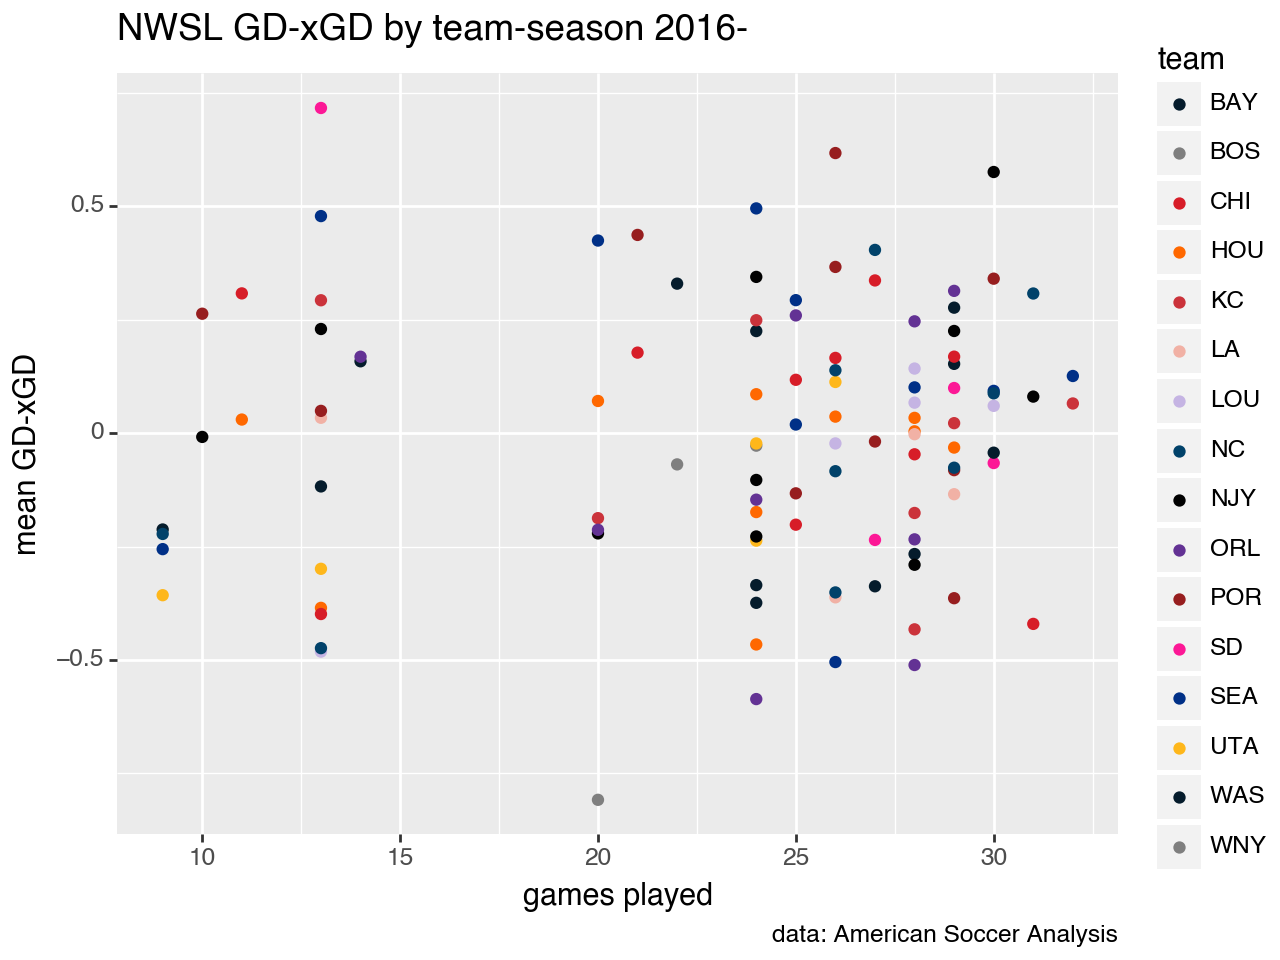

<Figure Size: (640 x 480)>

In [8]:
(
    ggplot(
        teams_df.query("count_games > 4"),
        aes(
            x="count_games", y="goal_difference_minus_xgoal_difference_pg", color="team"
        ),
    )
    + geom_point()
    + scale_color_manual(nwsl_primary_colors)
    + labs(
        y="mean GD-xGD",
        x="games played",
        title=f"NWSL GD-xGD by team-season {teams_df.season_name.min()}- ",
        caption="data: American Soccer Analysis",
    )
)

In [9]:
teams_df["current_season"] = "past"
teams_df.loc[teams_df.season_name == 2025, "current_season"] = "current"

/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/stats/binning.py:172: FutureWarning: The provided callable <function sum at 0x10db83670> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/stats/binning.py:172: FutureWarning: The provided callable <function sum at 0x10db83670> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


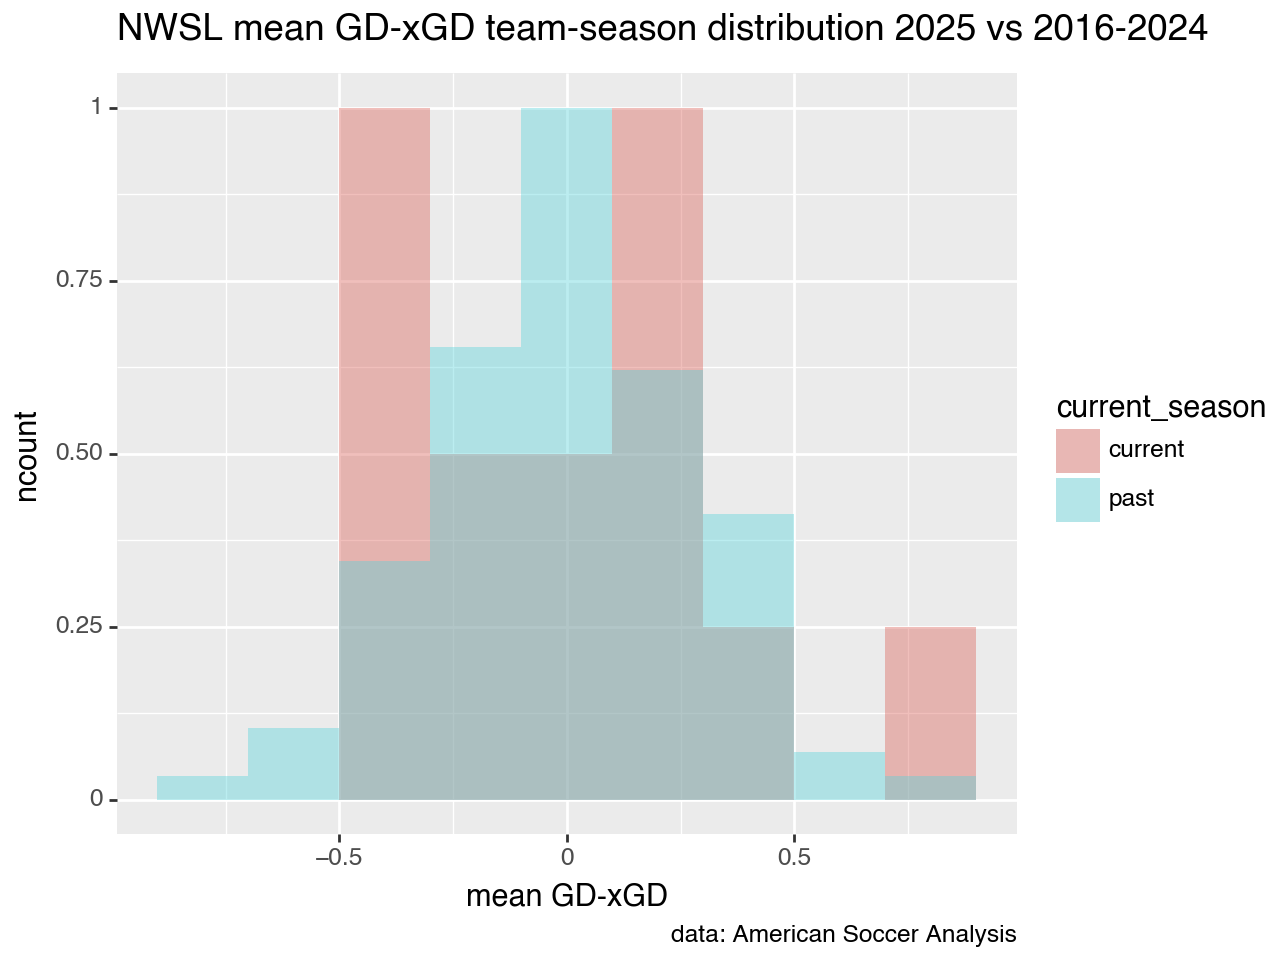

<Figure Size: (640 x 480)>

In [10]:
(
    ggplot(
        teams_df,
        aes(
            x="goal_difference_minus_xgoal_difference_pg",
            y=after_stat("ncount"),
            fill="current_season",
        ),
    )
    + geom_histogram(binwidth=0.2, alpha=0.4, position="identity")
    + labs(
        x="mean GD-xGD",
        title=f"NWSL mean GD-xGD team-season distribution {teams_df.season_name.max()} vs {teams_df.season_name.min()}-{teams_df.season_name.max()-1}",
        caption="data: American Soccer Analysis",
    )
)

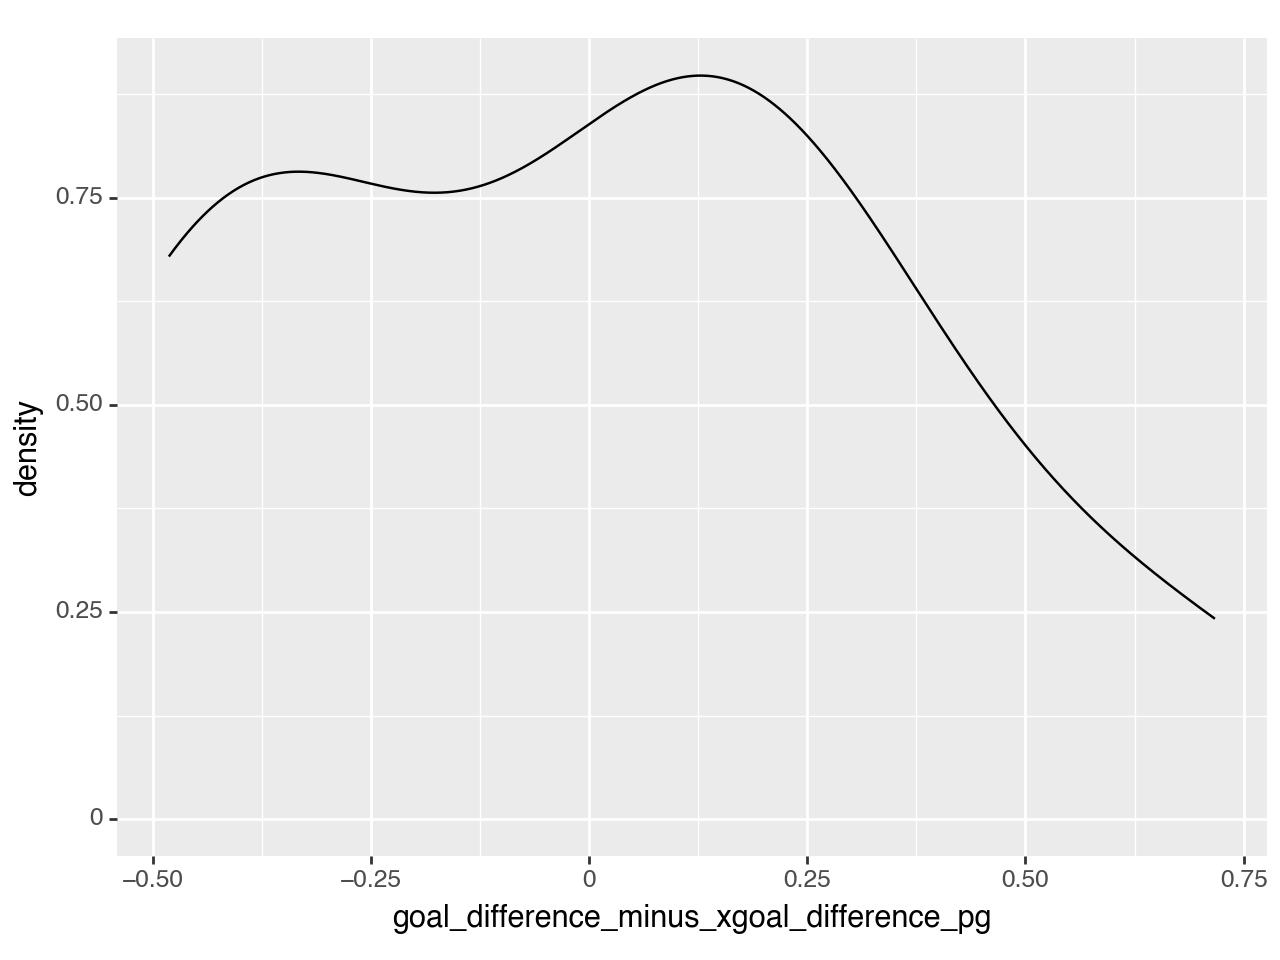

<Figure Size: (640 x 480)>

In [11]:
(
    ggplot(
        teams_df.query("(season_name == 2025)"),
        aes(x="goal_difference_minus_xgoal_difference_pg"),
    )
    + geom_density()
)

In [12]:
def decorate_game_ids(df):
    game_ids = df.game_id.unique()

    games_df = asa_client.get_games(game_ids=list(game_ids))

    return df.merge(games_df[["game_id", "date_time_utc"]], on="game_id")

In [13]:
teams_df = decorate_game_ids(
    decorate_team_ids(
        asa_client.get_team_xgoals(
            leagues="nwsl",
            # split_by_seasons=True,
            season_name="2025",
            split_by_games=True,
            stage_name="Regular Season",
        )
    )
).sort_values(["date_time_utc", "game_id"], ignore_index=True)

In [14]:
teams_df.date_time_utc = pd.to_datetime(teams_df.date_time_utc)

In [15]:
teams_df["points_total"] = teams_df.groupby("team").points.cumsum()
teams_df["games_total"] = teams_df.groupby("team").game_id.cumcount() + 1

teams_df["points_per_game"] = teams_df["points_total"] / teams_df["games_total"]

In [16]:
teams_df.groupby("team").last().reset_index()

,team,team_id,game_id,shots_for,shots_against,goals_for,goals_against,goal_difference,xgoals_for,xgoals_against,xgoal_difference,goal_difference_minus_xgoal_difference,points,xpoints,team_logo,date_time_utc,points_total,games_total,points_per_game
0,BAY,315VnJ759x,wvq9b8pwQW,11,7,1,2,-1,2.4102,0.9763,1.4340,-2.4340,0,2.394,https://american-soccer-analysis-headshots.s3....,2025-06-21 23:30:00+00:00,15,13,1.153846
1,CHI,KPqjw8PQ6v,315VpEe9Q9,6,12,0,1,-1,0.3812,1.0673,-0.6860,-0.3140,0,0.745,https://american-soccer-analysis-headshots.s3....,2025-06-22 02:00:00+00:00,6,13,0.461538
2,HOU,4JMAk47qKg,9z5kjkajMA,6,14,1,2,-1,0.3647,1.6901,-1.3254,0.3254,0,0.419,https://american-soccer-analysis-headshots.s3....,2025-06-21 23:30:00+00:00,11,13,0.846154
3,KC,4wM4rZdqjB,gOMnAL6XQw,13,3,1,0,1,1.7010,0.8645,0.8365,0.1635,3,2.081,https://american-soccer-analysis-headshots.s3....,2025-06-21 00:00:00+00:00,33,13,2.538462
4,LA,kRQa8JOqKZ,gOMnAL6XQw,3,13,0,1,-1,0.8645,1.7010,-0.8365,-0.1635,0,0.656,https://american-soccer-analysis-headshots.s3....,2025-06-21 00:00:00+00:00,15,13,1.153846
5,LOU,eV5DR6YQKn,vzqoKNrkqa,14,16,2,0,2,2.3162,0.9246,1.3916,0.6084,3,2.347,https://american-soccer-analysis-headshots.s3....,2025-06-21 00:00:00+00:00,20,13,1.538462
6,NC,zeQZeazqKw,9z5kjkajMA,14,6,2,1,1,1.6901,0.3647,1.3254,-0.3254,3,2.375,https://american-soccer-analysis-headshots.s3....,2025-06-21 23:30:00+00:00,18,13,1.384615
7,NJY,raMyrr25d2,wvq9b8pwQW,7,11,2,1,1,0.9763,2.4102,-1.4340,2.4340,3,0.459,https://american-soccer-analysis-headshots.s3....,2025-06-21 23:30:00+00:00,18,13,1.384615
8,ORL,XVqKeVKM01,vzqoKNrkqa,16,14,0,2,-2,0.9246,2.3162,-1.3916,-0.6084,0,0.472,https://american-soccer-analysis-headshots.s3....,2025-06-21 00:00:00+00:00,25,13,1.923077
9,POR,Pk5LeeNqOW,315VpEe9Q9,12,6,1,0,1,1.0673,0.3812,0.6860,0.3140,3,1.933,https://american-soccer-analysis-headshots.s3....,2025-06-22 02:00:00+00:00,22,13,1.692308


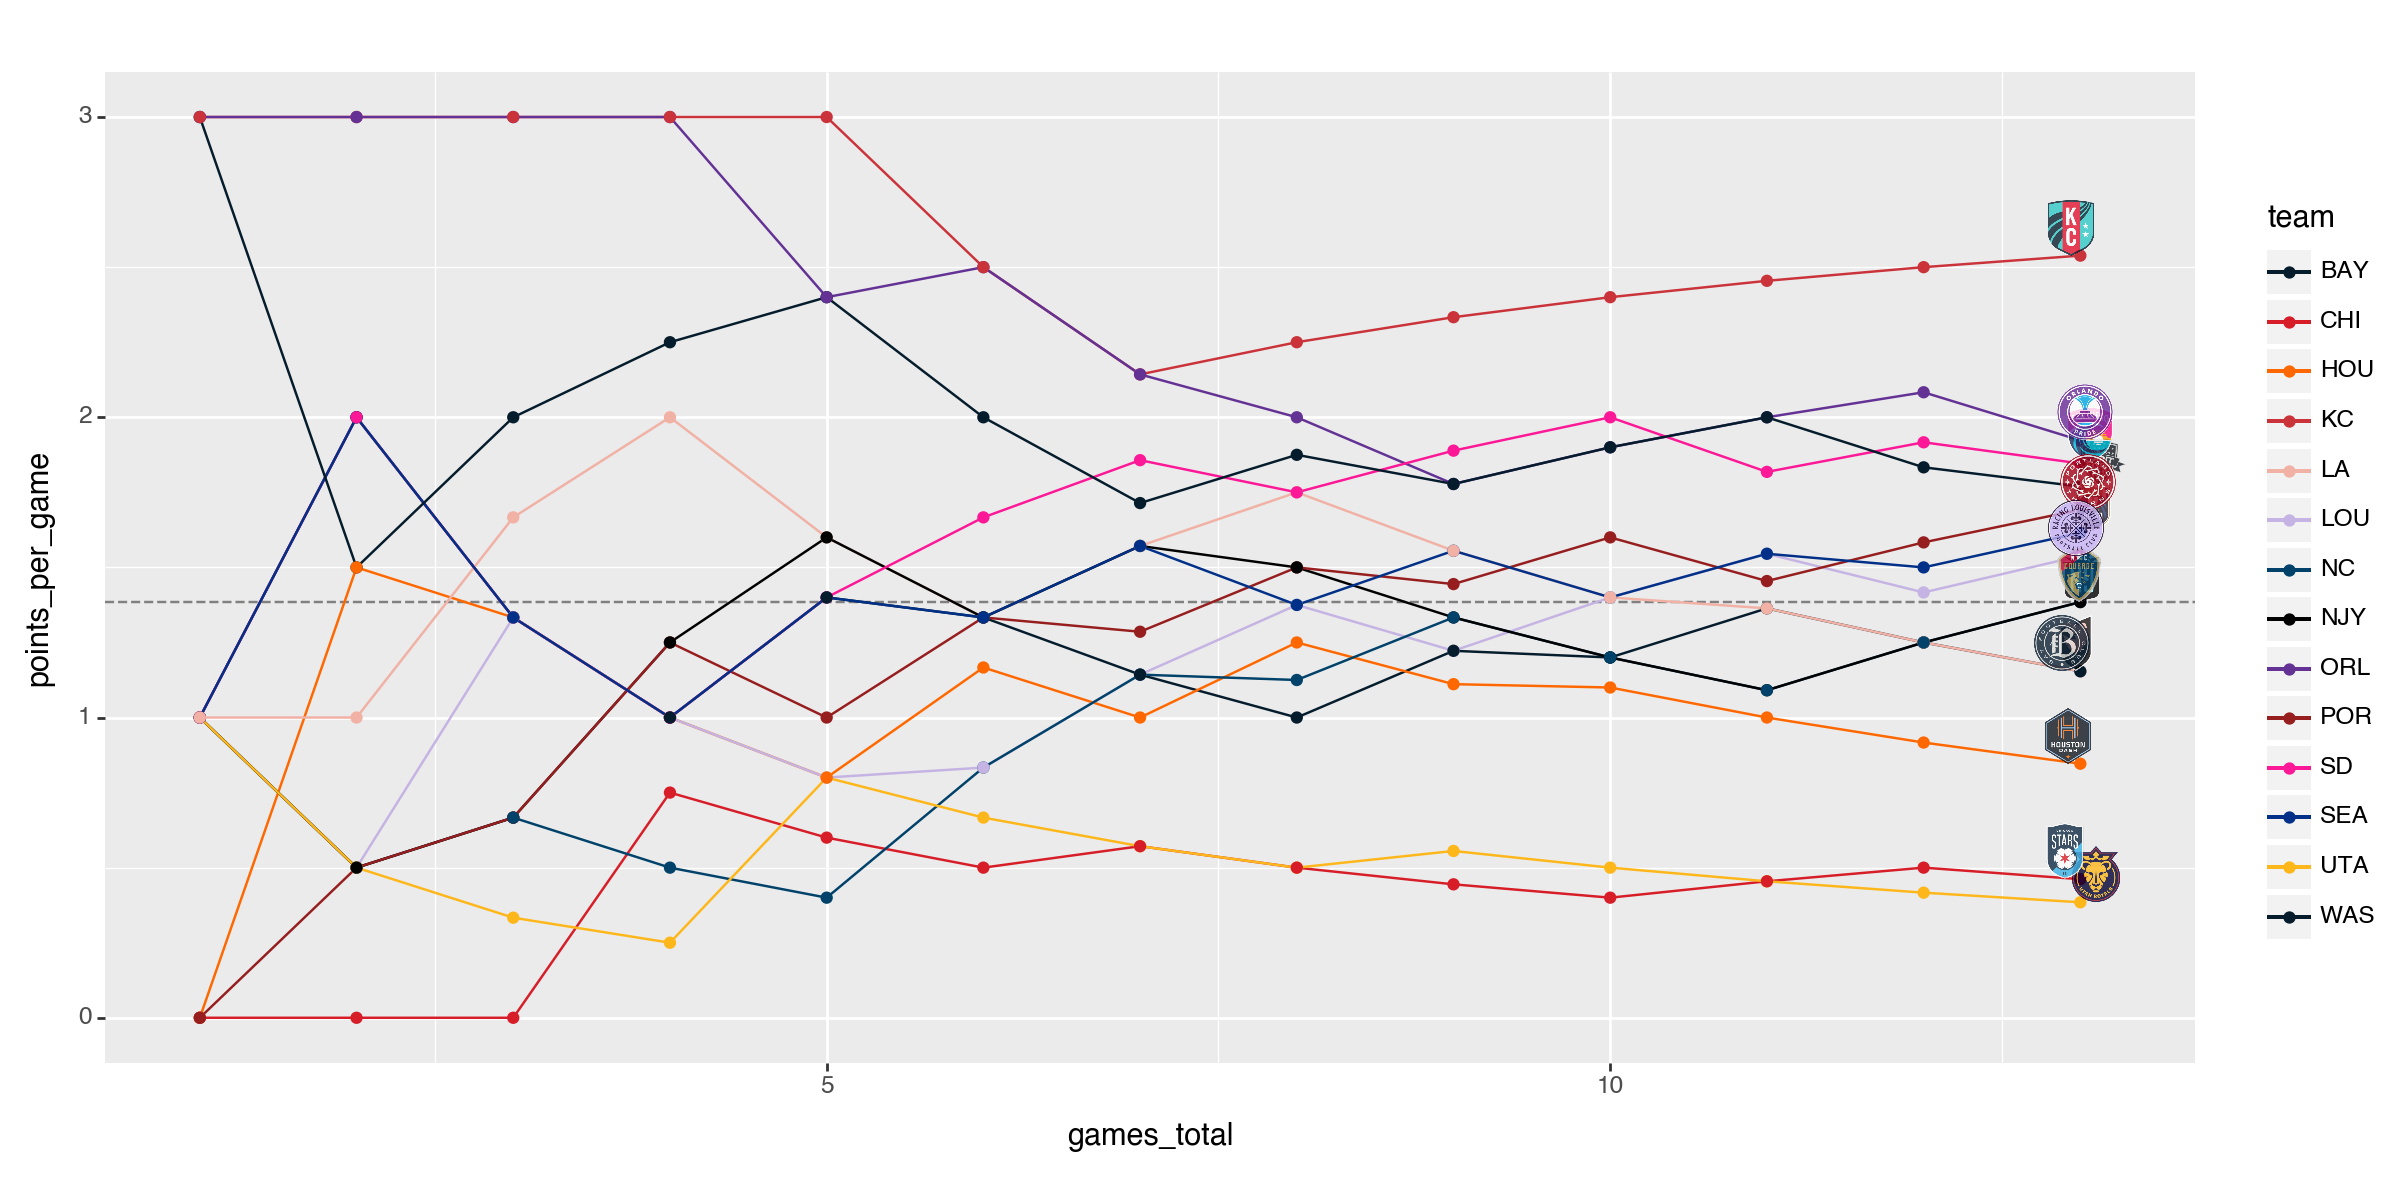

<Figure Size: (1200 x 600)>

In [17]:
(
    ggplot(
        teams_df,
        aes(x="games_total", y="points_per_game", color="team"),
    )
    + geom_hline(aes(yintercept=36 / 26), linetype="--", color="gray")
    + geom_line()
    + geom_point()
    + scale_color_manual(nwsl_primary_colors)
    + geom_image(
        teams_df.groupby("team").last().reset_index(),
        aes(image="team_logo"),
        alpha=0.8,
        position=position_dodge(width=0.25),
    )
    + theme(
        figure_size=(12, 6),
        # axis_text_x=element_text(angle=90),
    )
)

In [18]:
teams_df

,team_id,game_id,shots_for,shots_against,goals_for,goals_against,goal_difference,xgoals_for,xgoals_against,xgoal_difference,goal_difference_minus_xgoal_difference,points,xpoints,team,team_logo,date_time_utc,points_total,games_total,points_per_game
0,4JMAk47qKg,9YqdjO2jMv,10,8,1,2,-1,1.1262,1.2828,-0.1565,-0.8435,0,1.223,HOU,https://american-soccer-analysis-headshots.s3....,2025-03-15 00:00:00+00:00,0,1,0.000000
1,aDQ0lzvQEv,9YqdjO2jMv,8,10,2,1,1,1.2828,1.1262,0.1565,0.8435,3,1.439,WAS,https://american-soccer-analysis-headshots.s3....,2025-03-15 00:00:00+00:00,3,1,3.000000
2,KPqjw8PQ6v,KXMeZn0X56,8,27,0,5,-5,0.9863,2.3971,-1.4108,-3.5892,0,0.521,CHI,https://american-soccer-analysis-headshots.s3....,2025-03-15 00:00:00+00:00,0,1,0.000000
3,XVqKeVKM01,KXMeZn0X56,27,8,5,0,5,2.3971,0.9863,1.4108,3.5892,3,2.270,ORL,https://american-soccer-analysis-headshots.s3....,2025-03-15 00:00:00+00:00,3,1,3.000000
4,4wM4rZdqjB,odMXpkWrMY,15,12,3,1,2,1.9829,1.4012,0.5817,1.4183,3,1.796,KC,https://american-soccer-analysis-headshots.s3....,2025-03-15 16:45:00+00:00,3,1,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,raMyrr25d2,wvq9b8pwQW,7,11,2,1,1,0.9763,2.4102,-1.4340,2.4340,3,0.459,NJY,https://american-soccer-analysis-headshots.s3....,2025-06-21 23:30:00+00:00,18,13,1.384615
178,KPqjw8PQ6v,315VpEe9Q9,6,12,0,1,-1,0.3812,1.0673,-0.6860,-0.3140,0,0.745,CHI,https://american-soccer-analysis-headshots.s3....,2025-06-22 02:00:00+00:00,6,13,0.461538
179,Pk5LeeNqOW,315VpEe9Q9,12,6,1,0,1,1.0673,0.3812,0.6860,0.3140,3,1.933,POR,https://american-soccer-analysis-headshots.s3....,2025-06-22 02:00:00+00:00,22,13,1.692308
180,7VqG1lYMvW,EGMPadlV5a,16,7,0,0,0,0.6950,0.6184,0.0766,-0.0766,1,1.355,SD,https://american-soccer-analysis-headshots.s3....,2025-06-23 02:00:00+00:00,24,13,1.846154


In [19]:
games_df = asa_client.get_games(leagues="nwsl", seasons="2025")

In [20]:
shots_df = decorate_player_ids(
    decorate_team_ids(
        asa_client._get_stats(
            game_id=list(games_df.game_id), type="shots", entity="games", leagues="nwsl"
        )
    )
)

In [21]:
shots_df.T

,0,1,2,3,4,5,6,7,8,9,...,2160,2161,2162,2163,2164,2165,2166,2167,2168,2169
game_id,gjMNpdn0qK,0Oq6bZ8dq6,Pk5LpdmO5O,7VqGbYm65v,2vQ1bDaKMr,XVqKzJ1K50,jYQJmL1PqG,9vQ2bDdaQK,gpMOpdOE5z,KXMeZ6er56,...,gOMnALrXQw,raMyj2LO5d,0Oq6bZ8dq6,OlMljV70qL,Xj5Ypd8AMb,gOMnALrXQw,XVqKzJ1K50,0Oq6bZ8dq6,Xj5Ypd8AMb,ljqEmRjzqx
period_id,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
expanded_minute,1,1,1,1,1,1,1,1,2,2,...,97,100,102,103,104,98,96,103,105,97
game_minute,0,0,0,0,0,0,0,0,1,1,...,95,97,92,97,96,96,93,93,97,93
team_id,KPqjw8PQ6v,zeQZeazqKw,zeQZeazqKw,4wM4rZdqjB,aDQ0lzvQEv,KPqjw8PQ6v,KPqjw8PQ6v,XVqKeVKM01,4wM4rZdqjB,7vQ7BBzqD1,...,7VqG1lYMvW,315VnJ759x,raMyrr25d2,Pk5LeeNqOW,315VnJ759x,7VqG1lYMvW,4JMAk47qKg,zeQZeazqKw,Pk5LeeNqOW,7VqG1lYMvW
shooter_player_id,2lqRjRg2qr,vzqodvZjQa,vzqodvZjQa,odMX7LnxQY,xW5pr0w0Qg,9z5k7k7d5A,gpMOoKbnMz,BLMv7oZO5x,odMX8ElWMY,4JMAoyV2qK,...,XVqKYmW0M0,2lqRlkRnMr,9Yqd6LYoMv,gjMNPRApqK,0x5gLNAPq7,XVqKYmW0M0,p6qboZk4Q0,315VX01YQ9,BLMv78mR5x,7VqGj84Y5v
assist_player_id,0,2vQ143Ylqr,NWMWly9D5l,Xj5Y60lRqb,eVq3xWngQW,zeQZXkwD5K,vzqodLvBQa,0,gOMnR6AAMw,xW5prYLGQg,...,jYQJzzGkQG,0,9vQ223OaQK,0,9z5k7ENJ5A,EGMPnKgxqa,2lqRRG6xqr,KXMekJVvq6,7VqGjYPj5v,N6MmepOxME
shot_location_x,84.7,88.5,92.4,76.8,75.2,90.6,90.6,92.5,95.4,85.0,...,92.1,80.2,92.3,88.5,89.0,86.3,85.9,88.9,95.1,93.1
shot_location_y,46.4,64.1,45.8,45.6,36.8,50.5,66.2,32.4,56.7,40.1,...,34.2,35.2,38.0,50.0,61.7,73.7,63.0,35.0,47.3,53.7
shot_end_location_x,100.0,100.0,96.3,98.4,100.0,98.6,99.0,97.8,96.7,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,89.4,100.0,100.0,100.0


In [22]:
shots_df["great xG"] = shots_df.shot_xg >= 0.33
shots_df["good xG"] = (shots_df.shot_xg < 0.33) & (shots_df.shot_xg >= 0.15)

In [23]:
gb = (
    shots_df.query("goal == 0 & own_goal == 0")
    .groupby("team")[["great xG", "good xG"]]
    .sum()
)
gb["total"] = gb.sum(axis=1)
print("Shots missed:")
gb.sort_values("total", ascending=False)

Shots missed:


,great xG,good xG,total
team,,,
NC,11,29,40
KC,8,24,32
POR,6,26,32
ORL,7,22,29
WAS,4,21,25
LOU,5,18,23
BAY,3,17,20
LA,4,15,19
NJY,3,16,19
